## DART - LightGBM

**Objetivo:** desenvolver e avaliar modelos de previsão de PM2.5 com horizonte de 24 horas utilizando o LightGBM com dois algoritmos de boosting: GBDT (Gradient Boosting Decision Trees) e DART (Dropouts meet Multiple Additive  Regression Trees). O modelo incorpora variáveis meteorológicas, atributos temporais cíclicos, lags históricos da série e indicador sazonal de inverno.

*******
**Exploração e entendimento dos dados**
- Análise de ciclos sazonais (horário, semanal e anual) de PM2.5 e variáveis 
  meteorológicas;
- Correlação cruzada com lag entre PM2.5 e variáveis meteorológicas para 
  identificação de defasagens relevantes;
- Investigação da variabilidade mensal para identificação de períodos críticos 
  (inverno — junho a agosto).

************

**Experimentos DART/LightGBM**

Foram realizados diversos experimentos com o modelo DART/LightGBM para previsão de PM2.5 com horizonte de 24 horas. Os testes avaliaram diferentes configurações de:

- Inclusão de variáveis meteorológicas (temperatura, umidade relativa, precipitação e velocidade do vento);
- Inclusão de atributos temporais cíclicos (mês, dia da semana e hora representados por funções seno e cosseno);
- Inclusão de séries de Fourier para representação de sazonalidades de longo prazo;
- Diferentes conjuntos de lags da variável PM2.5;
- Ajuste dos hiperparâmetros do modelo.

************

**Conjunto de dados base utilizado**

      - 100% dos dados entre 2016-2019
      - train: (16104, 7) 2016-03-01 00:00:00+00:00 2017-12-31 23:00:00+00:00
      - val  : (8760, 7) 2018-01-01 00:00:00+00:00 2018-12-31 23:00:00+00:00
      - test : (5499, 7) 2019-01-01 00:00:00+00:00 2019-08-18 02:00:00+00:00

************

**Melhor Experimento**

- Modelo: LightGBM com boosting_type=gbdt
- Hiperparâmetros: otimizados via RandomizedSearchCV 
- Variáveis exógenas: temperatura, umidade relativa e velocidade do vento
- Features: temporais cíclicas + lags PM2.5 + lags meteorológicos [1,3,6,12,24h] + is_winter
- Tratamento de dados faltantes: sem interpolação

- Conjunto de dados: 100% dos dados (2016-2019) 

- Features:

    - Variáveis atmosféricas
    - Variáveis ciclicas
    - Lags de MP2.5
    - Lags das variáveis atmosféricas
    - flag de inverno


- Conjunto de dados:

      - train: (16104, 7) 2016-03-01 00:00:00+00:00 2017-12-31 23:00:00+00:00
      - val  : (8760, 7) 2018-01-01 00:00:00+00:00 2018-12-31 23:00:00+00:00
      - test : (5499, 7) 2019-01-01 00:00:00+00:00 2019-08-18 02:00:00+00:00

- Resultados obtidos no conjunto de validação em média:

    - MAE: 4,34 µg/m³
    - RMSE: 5,55 µg/m³
    - R²: 0,33

- Resultados obtidos no conjunto de teste em média:

    - MAE: 4,84 µg/m³
    - RMSE: 6,18 µg/m³
    - R²: 0,33

O LightGBM superou o SARIMAX em todas as métricas, com redução média de ~36% no MAE (39% na validação e 34% no teste). 
O DART não apresentou melhora em relação ao GBDT com os hiperparâmetros testados.

********************
**Ganho do LightGBM sobre o SARIMAX:**

- MAE validação: 4,34 vs 7,13 → melhora de 39%
- MAE teste: 4,84 vs 7,30 → melhora de 34%
- R² passou de negativo (-0,26 / -0,44) para positivo (0,33)

In [260]:
%matplotlib widget

In [261]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, root_mean_squared_error
from lightgbm import LGBMRegressor
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
import shap

shap.initjs();

### 1. Carregamento dos dados

In [262]:
# abrindo base de dados para treinamento/teste/validação
data = pd.read_csv("../data/data_sem_interpolacao/dados_full_feature_2016_2019_nan.csv")
data.head()

,time,MP2.5,temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m
0,2016-03-01 00:00:00+00:00,3.0,17.851000,95.075165,1.0,12.538134
1,2016-03-01 01:00:00+00:00,1.0,17.901001,95.983490,0.4,14.529915
2,2016-03-01 02:00:00+00:00,18.0,17.951000,95.380060,0.3,12.538134
3,2016-03-01 03:00:00+00:00,17.0,17.851000,96.285950,0.6,11.525623
4,2016-03-01 04:00:00+00:00,10.0,17.901001,95.983490,0.5,12.979984


In [263]:
data["time"] = pd.to_datetime(data["time"])
data = data.set_index("time").sort_index()

data.head()

,MP2.5,temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m
time,,,,,
2016-03-01 00:00:00+00:00,3.0,17.851000,95.075165,1.0,12.538134
2016-03-01 01:00:00+00:00,1.0,17.901001,95.983490,0.4,14.529915
2016-03-01 02:00:00+00:00,18.0,17.951000,95.380060,0.3,12.538134
2016-03-01 03:00:00+00:00,17.0,17.851000,96.285950,0.6,11.525623
2016-03-01 04:00:00+00:00,10.0,17.901001,95.983490,0.5,12.979984


### 2. Exploração da Série Temporal (Ciclos)

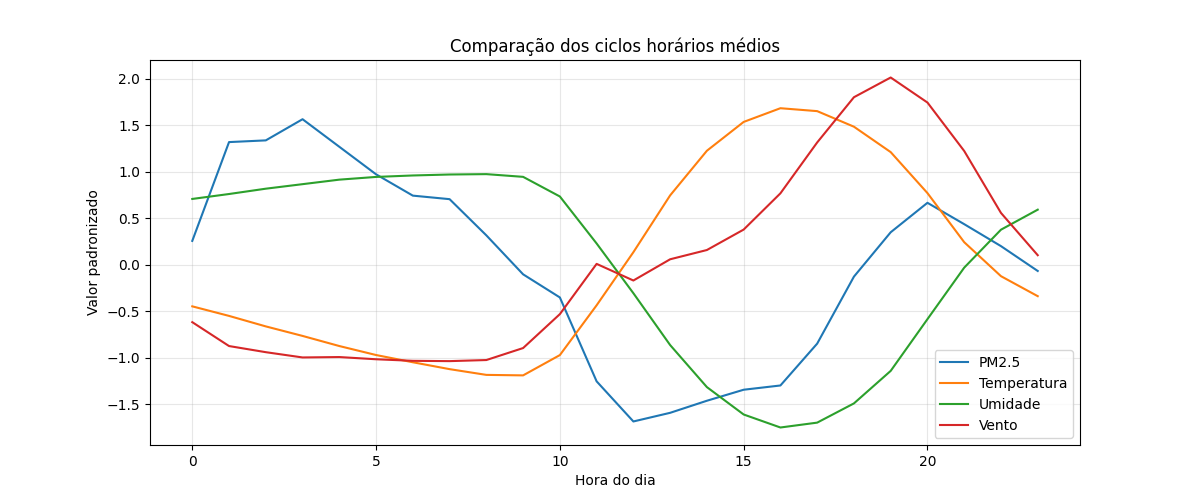

In [264]:
#ciclo diário
ciclo = pd.DataFrame({
    "PM2.5": data.groupby(data.index.hour)["MP2.5"].mean(),
    "Temperatura": data.groupby(data.index.hour)["temperature_2m"].mean(),
    "Umidade": data.groupby(data.index.hour)["relative_humidity_2m"].mean(),
    "Vento": data.groupby(data.index.hour)["wind_speed_10m"].mean()
})

ciclo_norm = pd.DataFrame(
    StandardScaler().fit_transform(ciclo),
    index=ciclo.index,
    columns=ciclo.columns
)

fig, ax = plt.subplots(figsize=(12,5))

ciclo_norm.plot(ax=ax)

ax.set_title("Comparação dos ciclos horários médios")
ax.set_xlabel("Hora do dia")
ax.set_ylabel("Valor padronizado")
ax.grid(alpha=0.3)

plt.show()

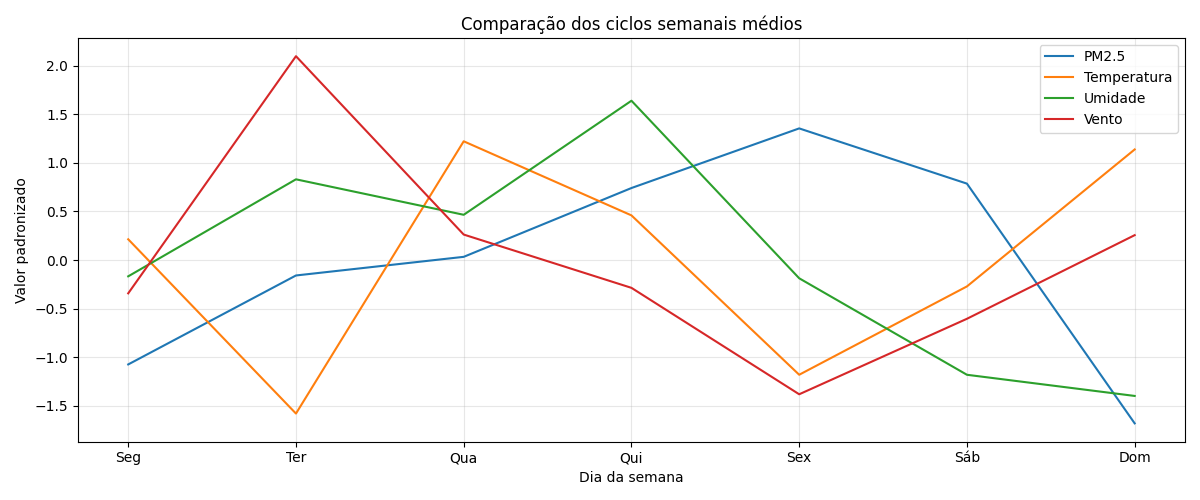

In [265]:
# ciclo semanal
ciclo = pd.DataFrame({
    "PM2.5": data.groupby(data.index.dayofweek)["MP2.5"].mean(),
    "Temperatura": data.groupby(data.index.dayofweek)["temperature_2m"].mean(),
    "Umidade": data.groupby(data.index.dayofweek)["relative_humidity_2m"].mean(),
    "Vento": data.groupby(data.index.dayofweek)["wind_speed_10m"].mean()
})

ciclo_norm = pd.DataFrame(
    StandardScaler().fit_transform(ciclo),
    index=ciclo.index,
    columns=ciclo.columns
)

dias = ["Seg", "Ter", "Qua", "Qui", "Sex", "Sáb", "Dom"]
ciclo_norm.index = dias

fig, ax = plt.subplots(figsize=(12,5))

ciclo_norm.plot(ax=ax)

ax.set_title("Comparação dos ciclos semanais médios")
ax.set_xlabel("Dia da semana")
ax.set_ylabel("Valor padronizado")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

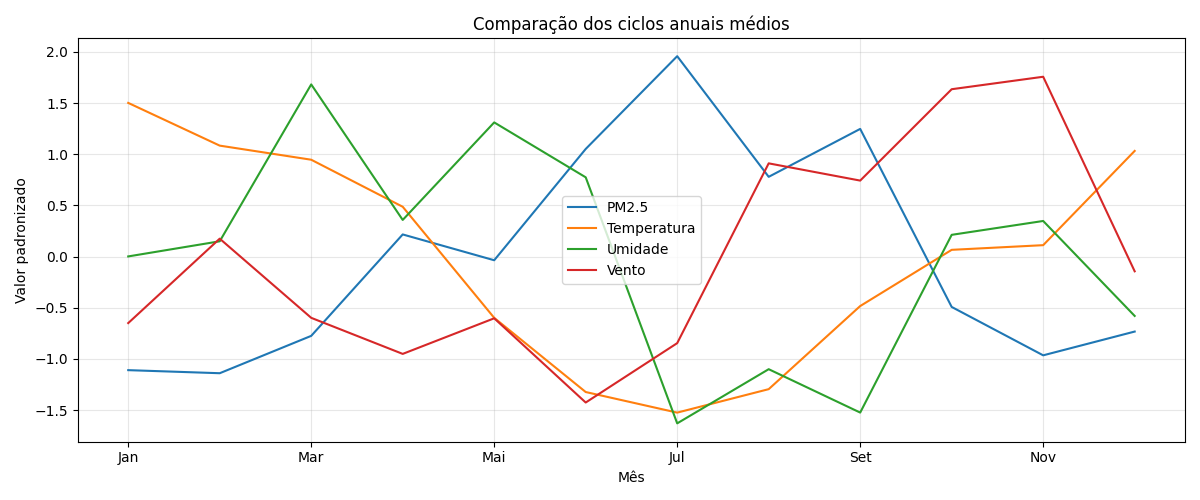

In [266]:
# ciclo anual
ciclo = pd.DataFrame({
    "PM2.5": data.groupby(data.index.month)["MP2.5"].mean(),
    "Temperatura": data.groupby(data.index.month)["temperature_2m"].mean(),
    "Umidade": data.groupby(data.index.month)["relative_humidity_2m"].mean(),
    "Vento": data.groupby(data.index.month)["wind_speed_10m"].mean()
})


ciclo_norm = pd.DataFrame(
    StandardScaler().fit_transform(ciclo),
    index=ciclo.index,
    columns=ciclo.columns
)

meses = [
    "Jan", "Fev", "Mar", "Abr",
    "Mai", "Jun", "Jul", "Ago",
    "Set", "Out", "Nov", "Dez"
]

ciclo_norm.index = meses

fig, ax = plt.subplots(figsize=(12,5))

ciclo_norm.plot(ax=ax)

ax.set_title("Comparação dos ciclos anuais médios")
ax.set_xlabel("Mês")
ax.set_ylabel("Valor padronizado")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 3. Correlação entre variáveis

In [267]:
######### Temperatura e PM25
# correlação cruzada consideranod lag (temperatura e PM25)
corr_temp = []

for lag in range(0, 100):

    c = data["MP2.5"].corr(
        data["temperature_2m"].shift(lag)
    )

    corr_temp.append(c)

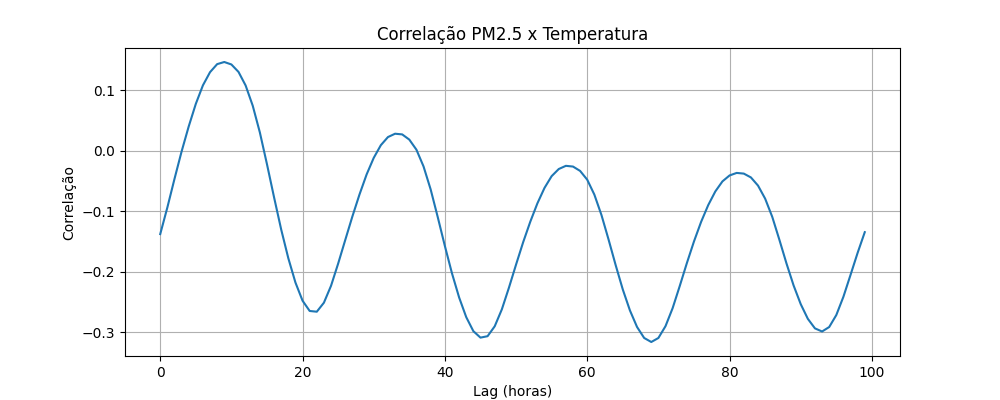

In [268]:
plt.figure(figsize=(10,4))

plt.plot(range(100), corr_temp)

plt.xlabel("Lag (horas)")
plt.ylabel("Correlação")
plt.title("Correlação PM2.5 x Temperatura")
plt.grid()

plt.show()

In [269]:
######### umidade e PM25
# correlação cruzada consideranod lag (temperatura e PM25)
corr_umi = []

for lag in range(0, 100):

    c = data["MP2.5"].corr(
        data["relative_humidity_2m"].shift(lag)
    )

    corr_umi.append(c)

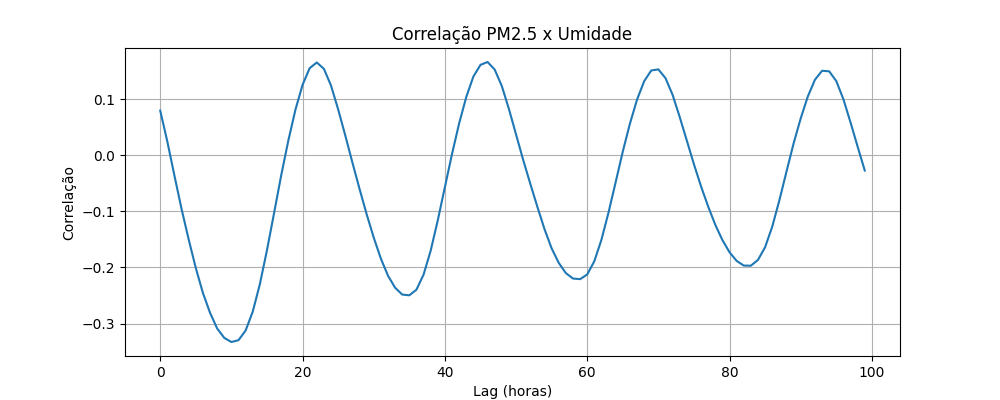

In [270]:
plt.figure(figsize=(10,4))

plt.plot(range(100), corr_umi)

plt.xlabel("Lag (horas)")
plt.ylabel("Correlação")
plt.title("Correlação PM2.5 x Umidade")
plt.grid()

plt.show()

In [271]:
corr_pm25 = []

for lag in range(0, 100):

    c = data["MP2.5"].corr(
        data["MP2.5"].shift(lag)
    )

    corr_pm25.append(c)

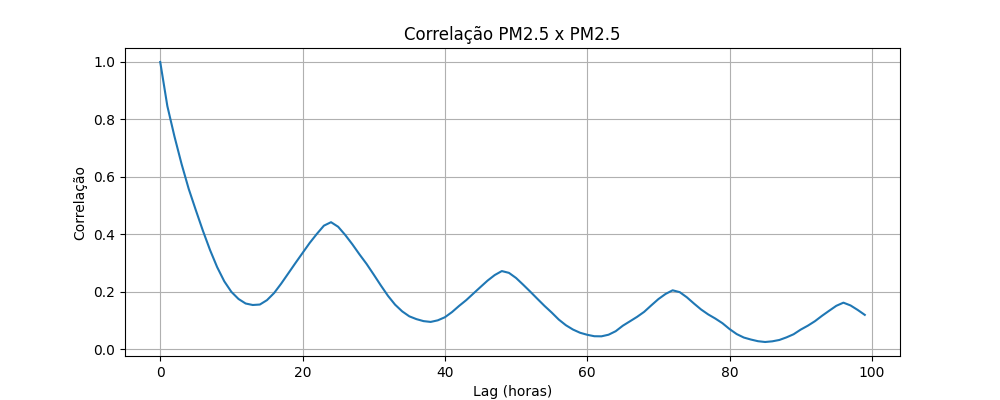

In [272]:
plt.figure(figsize=(10,4))

plt.plot(range(100), corr_pm25)

plt.xlabel("Lag (horas)")
plt.ylabel("Correlação")
plt.title("Correlação PM2.5 x PM2.5")
plt.grid()

plt.show()

In [273]:
######### vento e PM25
# correlação cruzada consideranod lag (temperatura e PM25)
corr_vento = []

for lag in range(0, 100):

    c = data["MP2.5"].corr(
        data["wind_speed_10m"].shift(lag)
    )

    corr_vento.append(c)

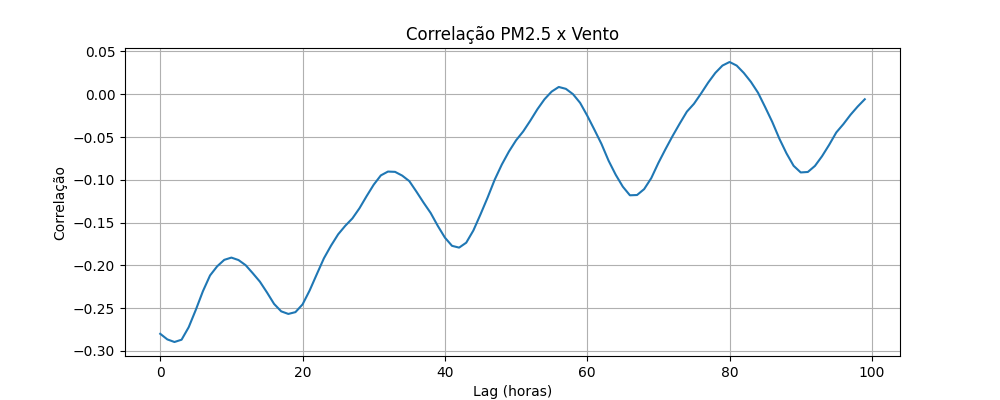

In [274]:
plt.figure(figsize=(10,4))

plt.plot(range(100), corr_vento)

plt.xlabel("Lag (horas)")
plt.ylabel("Correlação")
plt.title("Correlação PM2.5 x Vento")
plt.grid()

plt.show()

**Entendendo variabilidade anual**

In [275]:
pm25_mes = (data.groupby(data.index.month)["MP2.5"].mean())

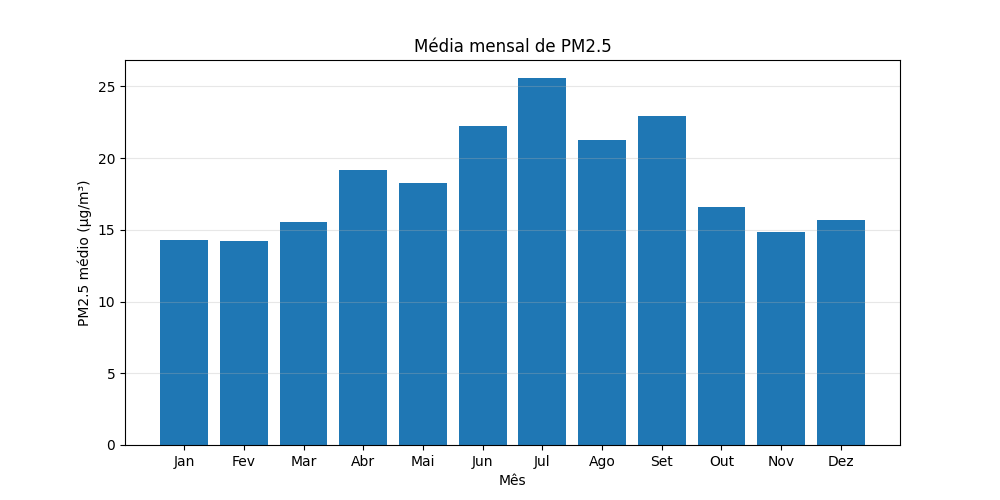

In [276]:
meses = [
    "Jan", "Fev", "Mar", "Abr", "Mai", "Jun",
    "Jul", "Ago", "Set", "Out", "Nov", "Dez"
]

plt.figure(figsize=(10,5))

plt.bar(
    meses,
    pm25_mes
)

plt.ylabel("PM2.5 médio (µg/m³)")
plt.xlabel("Mês")
plt.title("Média mensal de PM2.5")
plt.grid(axis="y", alpha=0.3)

plt.show()

### 4. Feature Engineering

In [277]:
data_lgbm = data.copy()

**Variáveis ciclicas temporais**

In [278]:
# Foram avaliadas diferentes features sazonais (ciclos diários, semanais e mensal) com o objetivo de melhorar a reprodução do modelo.
def cyclical_time_features(df):
    """
    Adiciona termos ciclicos como features exógenas
    df -> data

    """

    df = df.copy()

    df["month_sin"] = np.sin(2 * np.pi * df.index.month / 12)
    df["month_cos"] = np.cos(2 * np.pi * df.index.month / 12)


    df["weekday_sin"] = np.sin(2 * np.pi * df.index.dayofweek / 7)
    df["weekday_cos"] = np.cos(2 * np.pi * df.index.dayofweek / 7)


    df["hour_sin"] = np.sin(2 * np.pi * df.index.hour / 24)
    df["hour_cos"] = np.cos(2 * np.pi * df.index.hour / 24)

    return df

In [279]:
data_lgbm = cyclical_time_features(data_lgbm)

In [280]:
data_lgbm.head()

,MP2.5,temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m,month_sin,month_cos,weekday_sin,weekday_cos,hour_sin,hour_cos
time,,,,,,,,,,,
2016-03-01 00:00:00+00:00,3.0,17.851000,95.075165,1.0,12.538134,1.0,6.123234e-17,0.781831,0.62349,0.000000,1.000000
2016-03-01 01:00:00+00:00,1.0,17.901001,95.983490,0.4,14.529915,1.0,6.123234e-17,0.781831,0.62349,0.258819,0.965926
2016-03-01 02:00:00+00:00,18.0,17.951000,95.380060,0.3,12.538134,1.0,6.123234e-17,0.781831,0.62349,0.500000,0.866025
2016-03-01 03:00:00+00:00,17.0,17.851000,96.285950,0.6,11.525623,1.0,6.123234e-17,0.781831,0.62349,0.707107,0.707107
2016-03-01 04:00:00+00:00,10.0,17.901001,95.983490,0.5,12.979984,1.0,6.123234e-17,0.781831,0.62349,0.866025,0.500000


**Variáveis meteorológicas com lags**

In [281]:
# vou usar apenas temperatura, vento e umidade que parecem ter maior corelação com lag
met_vars = [
    "temperature_2m",
    "relative_humidity_2m",
    "wind_speed_10m",
]

for var in met_vars:
    if var in data_lgbm.columns:
        for lag in [1, 3, 6, 12, 24]:
            data_lgbm[f"{var}_lag{lag}"] = data_lgbm[var].shift(lag)

data_lgbm.head()

,MP2.5,temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m,month_sin,month_cos,weekday_sin,weekday_cos,hour_sin,...,relative_humidity_2m_lag1,relative_humidity_2m_lag3,relative_humidity_2m_lag6,relative_humidity_2m_lag12,relative_humidity_2m_lag24,wind_speed_10m_lag1,wind_speed_10m_lag3,wind_speed_10m_lag6,wind_speed_10m_lag12,wind_speed_10m_lag24
time,,,,,,,,,,,,,,,,,,,,,
2016-03-01 00:00:00+00:00,3.0,17.851000,95.075165,1.0,12.538134,1.0,6.123234e-17,0.781831,0.62349,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-03-01 01:00:00+00:00,1.0,17.901001,95.983490,0.4,14.529915,1.0,6.123234e-17,0.781831,0.62349,0.258819,...,95.075165,NaN,NaN,NaN,NaN,12.538134,NaN,NaN,NaN,NaN
2016-03-01 02:00:00+00:00,18.0,17.951000,95.380060,0.3,12.538134,1.0,6.123234e-17,0.781831,0.62349,0.500000,...,95.983490,NaN,NaN,NaN,NaN,14.529915,NaN,NaN,NaN,NaN
2016-03-01 03:00:00+00:00,17.0,17.851000,96.285950,0.6,11.525623,1.0,6.123234e-17,0.781831,0.62349,0.707107,...,95.380060,95.075165,NaN,NaN,NaN,12.538134,12.538134,NaN,NaN,NaN
2016-03-01 04:00:00+00:00,10.0,17.901001,95.983490,0.5,12.979984,1.0,6.123234e-17,0.781831,0.62349,0.866025,...,96.285950,95.983490,NaN,NaN,NaN,11.525623,14.529915,NaN,NaN,NaN


In [282]:
# lag negativo = valor futuro da variável meteorológica
# na ferramenta operacional terei acesso às previsões atmosféricas.
# for var in ["temperature_2m", "relative_humidity_2m", "wind_speed_10m"]:
#     for h in [1, 3, 6, 12, 24]:
#         data_lgbm[f"{var}_future{h}"] = data_lgbm[var].shift(-h)

**Lags temporais do target (MP2.5)**

In [283]:
for lag in [1, 2, 3, 6, 12, 24, 48, 168]:
    data_lgbm[f"pm25_lag{lag}"] = data_lgbm["MP2.5"].shift(lag)

data_lgbm.head()

,MP2.5,temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m,month_sin,month_cos,weekday_sin,weekday_cos,hour_sin,...,wind_speed_10m_lag12,wind_speed_10m_lag24,pm25_lag1,pm25_lag2,pm25_lag3,pm25_lag6,pm25_lag12,pm25_lag24,pm25_lag48,pm25_lag168
time,,,,,,,,,,,,,,,,,,,,,
2016-03-01 00:00:00+00:00,3.0,17.851000,95.075165,1.0,12.538134,1.0,6.123234e-17,0.781831,0.62349,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-03-01 01:00:00+00:00,1.0,17.901001,95.983490,0.4,14.529915,1.0,6.123234e-17,0.781831,0.62349,0.258819,...,NaN,NaN,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-03-01 02:00:00+00:00,18.0,17.951000,95.380060,0.3,12.538134,1.0,6.123234e-17,0.781831,0.62349,0.500000,...,NaN,NaN,1.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN
2016-03-01 03:00:00+00:00,17.0,17.851000,96.285950,0.6,11.525623,1.0,6.123234e-17,0.781831,0.62349,0.707107,...,NaN,NaN,18.0,1.0,3.0,NaN,NaN,NaN,NaN,NaN
2016-03-01 04:00:00+00:00,10.0,17.901001,95.983490,0.5,12.979984,1.0,6.123234e-17,0.781831,0.62349,0.866025,...,NaN,NaN,17.0,18.0,1.0,NaN,NaN,NaN,NaN,NaN


**indicador de inverno (mês de poluição mais extrema)**

In [284]:
# a reprodução dos meses de inverno teve o pior desempenho no SARIMAX
data_lgbm["is_winter"] = data_lgbm.index.month.isin([6, 7, 8]).astype(int)
data_lgbm.head()

,MP2.5,temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m,month_sin,month_cos,weekday_sin,weekday_cos,hour_sin,...,wind_speed_10m_lag24,pm25_lag1,pm25_lag2,pm25_lag3,pm25_lag6,pm25_lag12,pm25_lag24,pm25_lag48,pm25_lag168,is_winter
time,,,,,,,,,,,,,,,,,,,,,
2016-03-01 00:00:00+00:00,3.0,17.851000,95.075165,1.0,12.538134,1.0,6.123234e-17,0.781831,0.62349,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
2016-03-01 01:00:00+00:00,1.0,17.901001,95.983490,0.4,14.529915,1.0,6.123234e-17,0.781831,0.62349,0.258819,...,NaN,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
2016-03-01 02:00:00+00:00,18.0,17.951000,95.380060,0.3,12.538134,1.0,6.123234e-17,0.781831,0.62349,0.500000,...,NaN,1.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN,0
2016-03-01 03:00:00+00:00,17.0,17.851000,96.285950,0.6,11.525623,1.0,6.123234e-17,0.781831,0.62349,0.707107,...,NaN,18.0,1.0,3.0,NaN,NaN,NaN,NaN,NaN,0
2016-03-01 04:00:00+00:00,10.0,17.901001,95.983490,0.5,12.979984,1.0,6.123234e-17,0.781831,0.62349,0.866025,...,NaN,17.0,18.0,1.0,NaN,NaN,NaN,NaN,NaN,0


**Janela móvel (rolling)**

In [285]:
for window in [6, 12, 24, 48]:
    base = data_lgbm["MP2.5"].shift(1)
    data_lgbm[f"pm25_mean_{window}h"] = base.rolling(window).mean()
    data_lgbm[f"pm25_std_{window}h"]  = base.rolling(window).std()
    data_lgbm[f"pm25_max_{window}h"]  = base.rolling(window).max()

data_lgbm.shape

(30363, 47)

### 5. Separando conjunto de treino, validação e teste

In [286]:
def split_temporal_lgbm(
    df,
    target,
    train_end="2018-01-01",
    val_end="2019-01-01"
):
    """
    Separação do conjunto de dados em: Treino, Teste e Validação

    """

    df = df.copy()
    df = df.sort_index()

    feature_cols = [c for c in df.columns if c != target]

    train = df.loc[df.index < train_end].copy()
    val = df.loc[(df.index >= train_end) & (df.index < val_end)].copy()
    test = df.loc[df.index >= val_end].copy()

    X_train, y_train = train[feature_cols], train[target]
    X_val,   y_val   = val[feature_cols],   val[target]
    X_test,  y_test  = test[feature_cols],  test[target]

    print("train:", train.shape, train.index.min(), train.index.max())
    print("val  :", val.shape,   val.index.min(),   val.index.max())
    print("test :", test.shape,  test.index.min(),  test.index.max())


    return X_train, X_val, X_test, y_train, y_val, y_test

In [287]:
X_train, X_val, X_test, y_train, y_val, y_test = split_temporal_lgbm(
    data_lgbm,
    target="MP2.5",
    train_end="2018-01-01",
    val_end="2019-01-01"
)


train: (16104, 47) 2016-03-01 00:00:00+00:00 2017-12-31 23:00:00+00:00
val  : (8760, 47) 2018-01-01 00:00:00+00:00 2018-12-31 23:00:00+00:00
test : (5499, 47) 2019-01-01 00:00:00+00:00 2019-08-18 02:00:00+00:00


In [288]:
X_train.shape, y_train.shape

((16104, 46), (16104,))

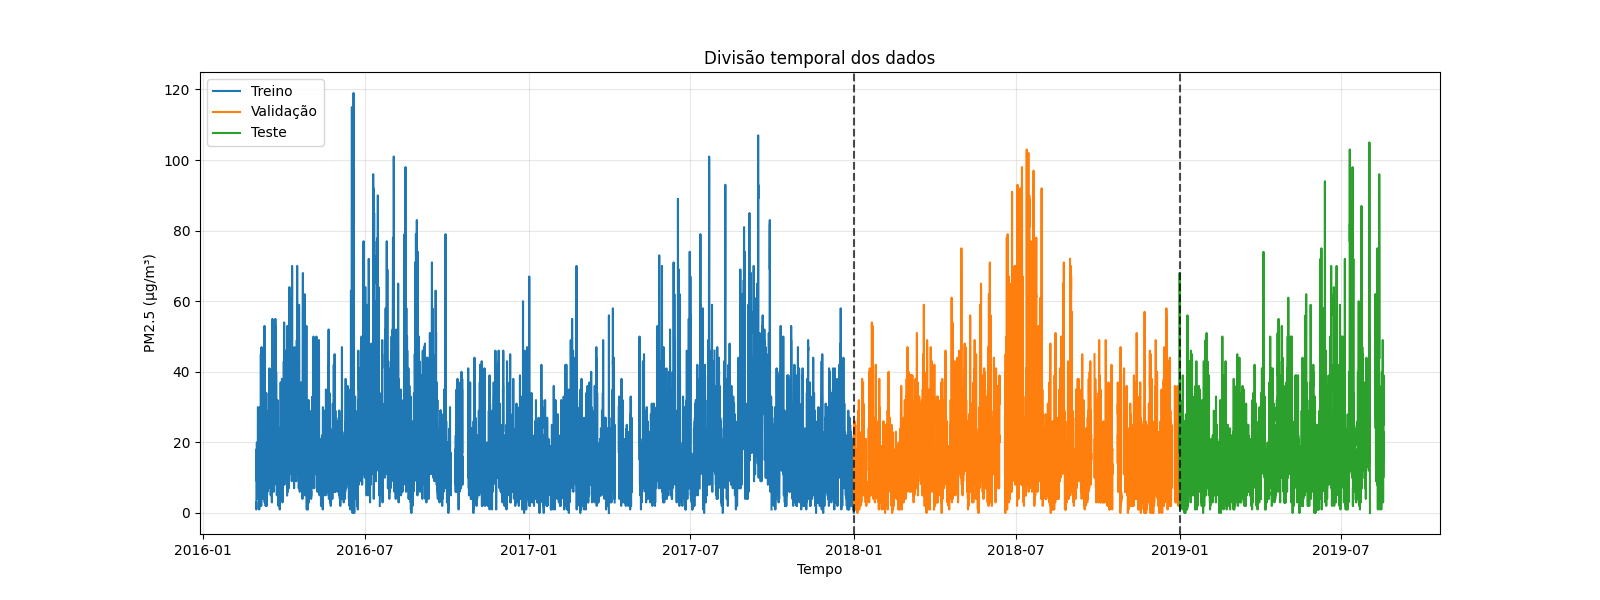

In [289]:
plt.figure(figsize=(16,6))

plt.plot(
    y_train,
    label="Treino",
    color="tab:blue"
)

plt.plot(
    y_val,
    label="Validação",
    color="tab:orange"
)

plt.plot(
    y_test,
    label="Teste",
    color="tab:green"
)

plt.axvline(
    y_val.index[0],
    color="black",
    linestyle="--",
    alpha=0.7
)

plt.axvline(
    y_test.index[0],
    color="black",
    linestyle="--",
    alpha=0.7
)

plt.title("Divisão temporal dos dados")
plt.ylabel("PM2.5 (µg/m³)")
plt.xlabel("Tempo")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

### 6. Baseline simples

In [290]:
# Seasonal Naive (24h) - utilizado nas rodas simples do modelo (item 9.1)
# observado nas primeiras 24h do teste
y_true = y_val.iloc[:24]

# Baseline = ultimas 24h do treino
y_baseline = y_train.iloc[-24:].copy()

y_baseline.index = y_true.index

mae_baseline = mean_absolute_error(y_true, y_baseline)
rmse_baseline = root_mean_squared_error(y_true, y_baseline)
r2_baseline = r2_score(y_true, y_baseline)

print(f"Baseline 24h - MAE : {mae_baseline:.3f}")
print(f"Baseline 24h - RMSE: {rmse_baseline:.3f}")
print(f"Baseline 24h - R²  : {r2_baseline:.3f}")

Baseline 24h - MAE : 5.375
Baseline 24h - RMSE: 7.536
Baseline 24h - R²  : -0.304


### 7. Modelagem

**7.1 Modelo único para testes**

In [291]:
model = LGBMRegressor(
    n_estimators=100,
    learning_rate=0.05,
    num_leaves=31,
    min_child_samples=50,
    min_child_weight=0.1,
    max_depth=15,
    subsample=0.6,
    colsample_bytree=0.8,
    reg_lambda=0.0,
    reg_alpha=0.1,
    random_state=42,
    verbose=-1
)

In [292]:
results =  model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    eval_metric="mae",
    eval_names=["treino", "validação"]
)

In [293]:
#  Feature importance — diagnóstico do modelo

def plot_feature_importance(model, X_train, top_n=20):
    """
    Mostra quais features o modelo está usando de fato.
    """
    imp = pd.Series(
        model.feature_importances_,
        index=X_train.columns
    ).sort_values(ascending=False).head(top_n)

    fig, ax = plt.subplots(figsize=(10, 6))
    imp.plot(kind="barh", ax=ax)
    ax.invert_yaxis()
    ax.set_title(f"Feature Importance — Top {top_n}")
    ax.set_xlabel("Importância")
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    return imp

In [294]:
def prever_24h(model, X_val, horizon=24):
    """
    Previsão das próximas 24h — usa features já calculadas.
    Equivalente ao get_forecast do SARIMAX.
    """
    X_future = X_val.iloc[:horizon]
    y_pred   = model.predict(X_future)

    return pd.Series(y_pred, index=X_future.index, name="forecast")

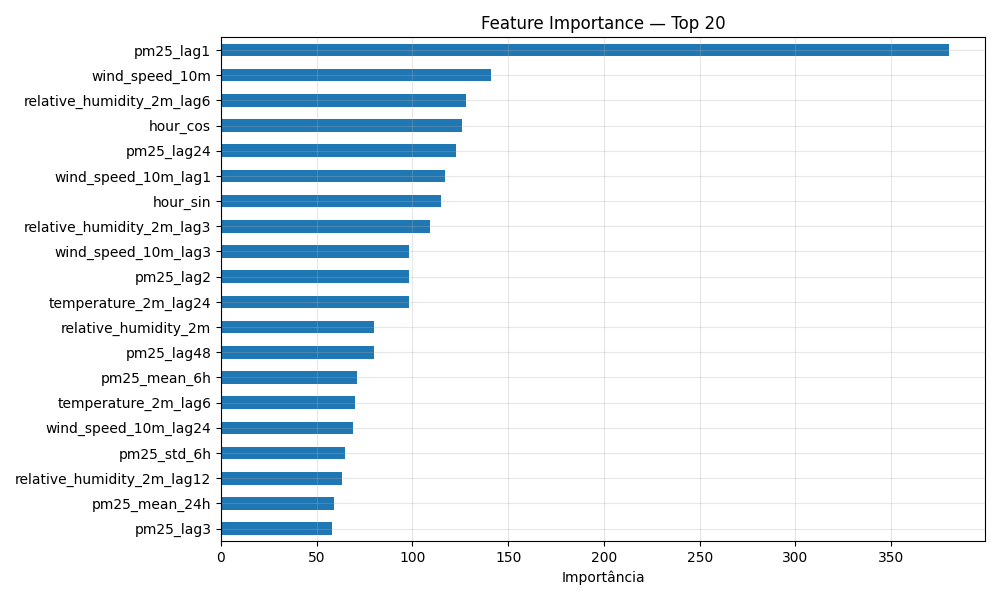

In [295]:
# feature importance
plot_feature_importance(results, X_train);


**SHAP - Local explainability**

In [296]:
# SHAP
model_to_explain = model

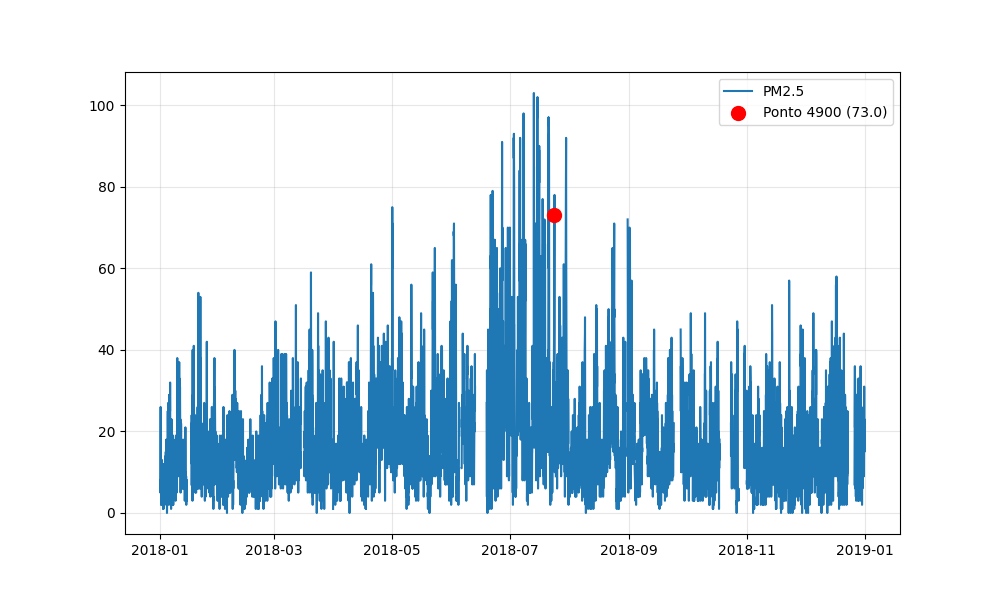

In [297]:
plt.figure(figsize=(10, 6))

plt.plot(y_val, label="PM2.5")

# pico 4900
# cava 24
plt.scatter(
    y_val.index[4900],
    y_val.iloc[4900],
    color="red",
    s=100,
    zorder=5,
    label=f"Ponto 4900 ({y_val.iloc[4900]:.1f})"
)

plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [298]:
# verificar previsão nos picos
y_val.iloc[4900]

np.float64(73.0)

In [299]:
row_to_show = 4900 #escolha do ponto de previsão - 4900 para pico 24 para cava

feature_values = X_val.iloc[[row_to_show]]
prediction = model_to_explain.predict(feature_values)

print(f"Previsão para essa janela: {prediction[0]:.3f} para o ponto {row_to_show}")

Previsão para essa janela: 70.954 para o ponto 4900


In [300]:
explainer = shap.Explainer(model_to_explain)

shap_values_one = explainer(feature_values)

In [301]:

print(f"{'Valor de base:':<35}{shap_values_one.base_values[0]:>7.3f}")
print(f"{'Soma dos valores de SHAP:':<35}{shap_values_one.values.sum():>7.3f}")
print(f"{'Previsão para o instante:':<35}{prediction[0]:>7.3f}")


Valor de base:                      18.029
Soma dos valores de SHAP:           52.925
Previsão para o instante:           70.954


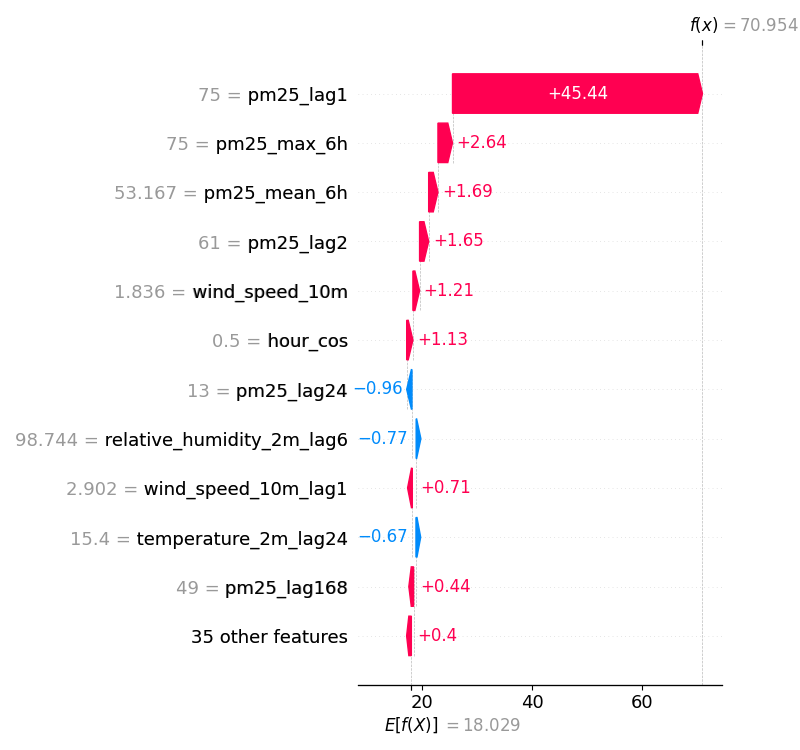

In [302]:
plt.figure(figsize=(10, 6))

shap.plots.waterfall(
    shap_values_one[0],
    max_display=12,
    show=False
)

plt.tight_layout()
plt.show()

Interpretação:

      - Nos picos (ponto 4900):
        - Variável que mais influencia: MP2.5 de 1h antes influenciando positivamente (aumentando o valor de MP2.5)
      - Nas cavas (ponto 24):
        - Variável que mais influencia: MP2.5 de 1h (diminuirndo o valor de MP2.5). Vento e umidade tbm começa a ter importância (positiva).


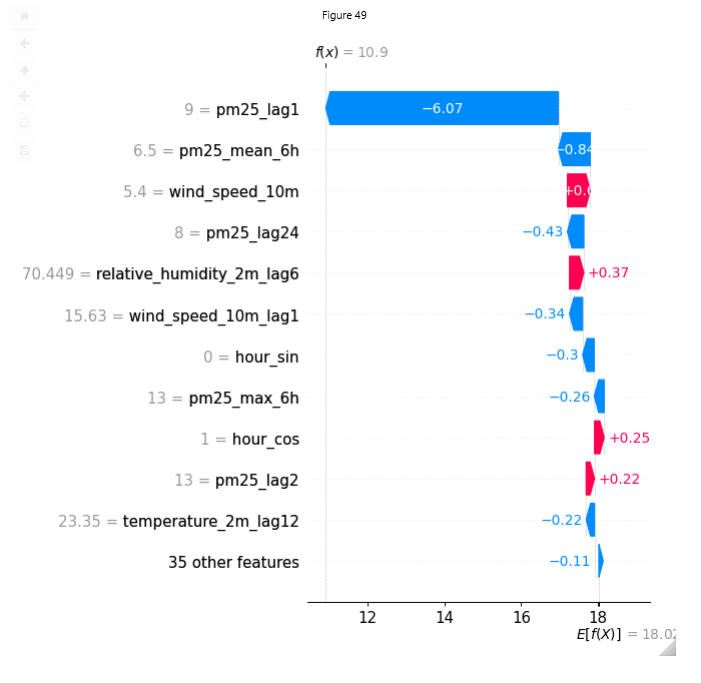

**SHAP - Global explainability**

In [303]:
shap_values = explainer(X_val)

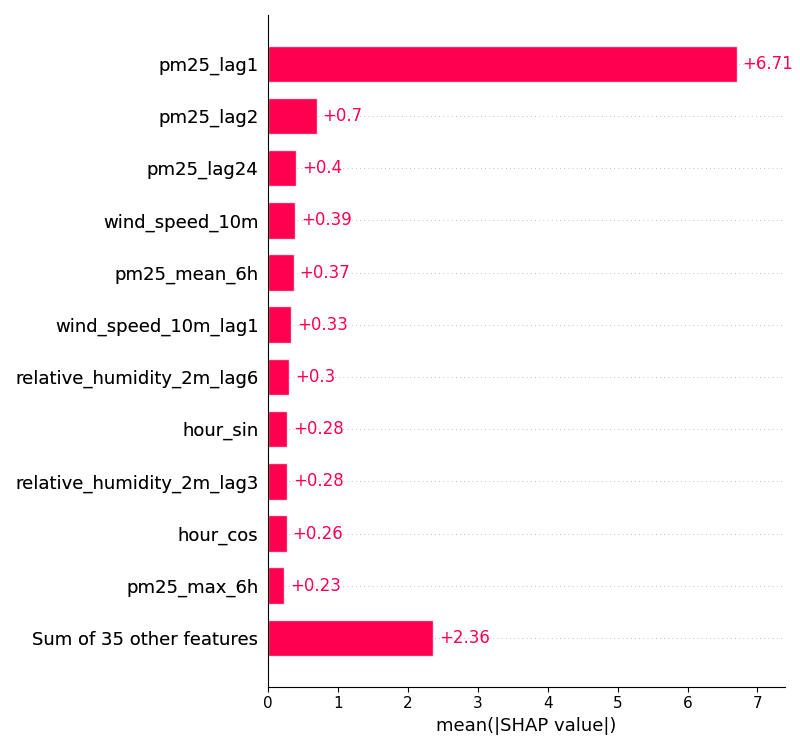

In [304]:
plt.figure(figsize=(10, 6))

shap.plots.bar(shap_values,
    max_display=12,
    show=False
)

plt.tight_layout()
plt.show()

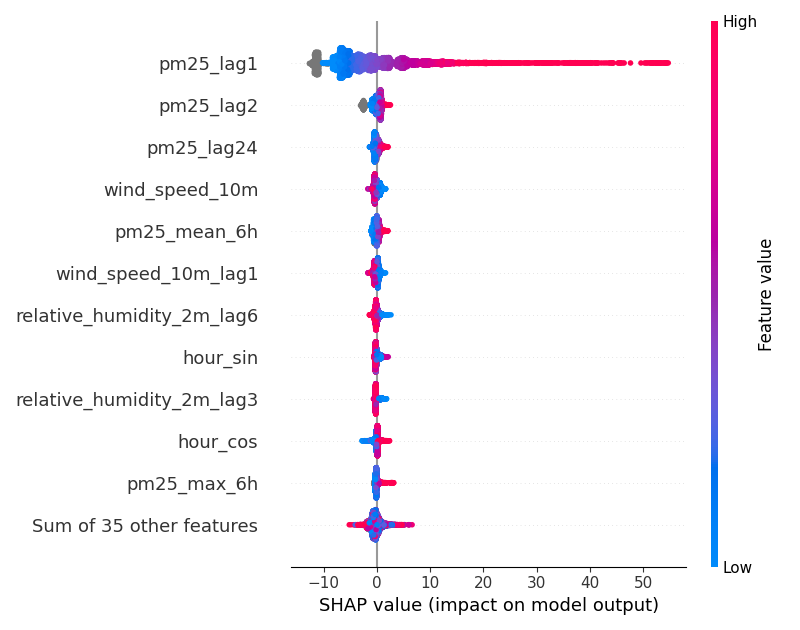

In [305]:
plt.figure(figsize=(10, 6))

shap.plots.beeswarm(shap_values,
    max_display=12,
    show=False
)

plt.tight_layout()
plt.show()

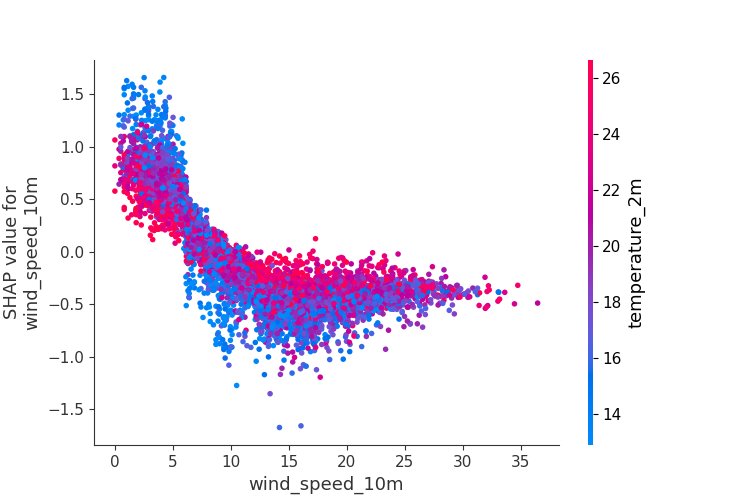

In [306]:
plt.figure(figsize=(10, 6))
shap.dependence_plot(
    "wind_speed_10m",
    shap_values.values,
    X_val
)

Interpretação:

        Ventos menores que 15m/s, SHAP positivo -> aumenta a previsao de MP2.5
        Ventos maiores que 15m/s, SHAP negativo -> diminui a previsao de MP2.5
        Temperatura também tem influência associada aos ventos

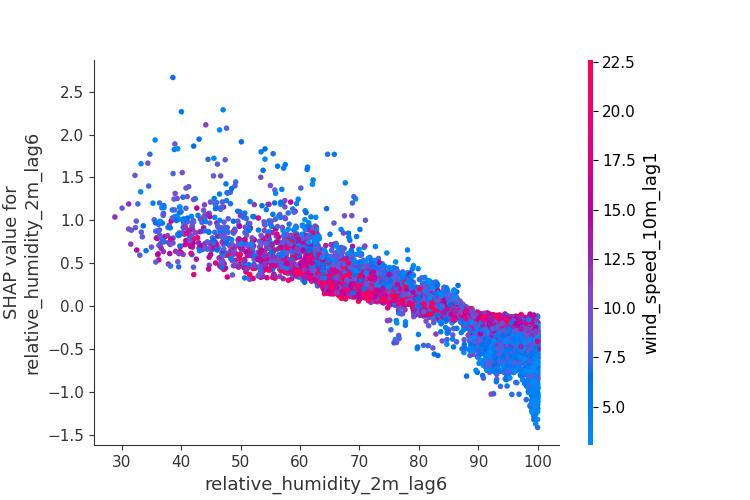

In [307]:
plt.figure(figsize=(10, 6))
shap.dependence_plot(
    "relative_humidity_2m_lag6",
    shap_values.values,
    X_val
)

Interpretação:

        Umidade menores que 70/80 (ventos fracos), SHAP positivo -> aumenta a previsao de MP2.5
        Ventos maiores que 70/80, SHAP negativo -> diminui a previsao de MP2.5 (possível chuva)

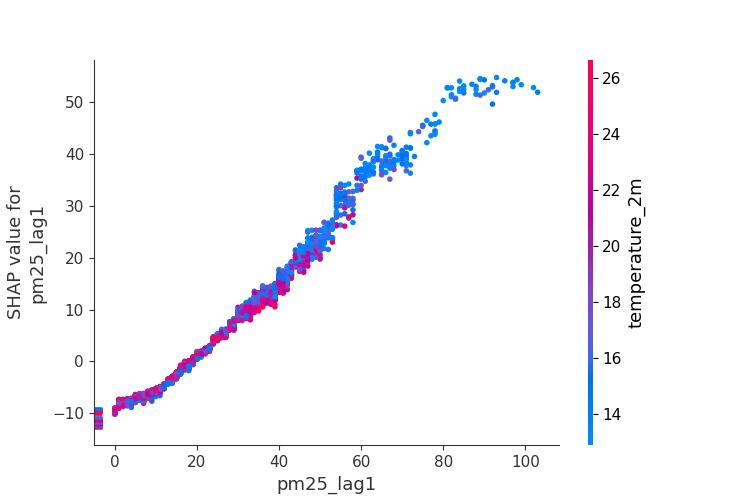

In [308]:
plt.figure(figsize=(10, 6))
shap.dependence_plot(
    "pm25_lag1",
    shap_values.values,
    X_val
)

Interpretação:

        pm25_lag1 tem SHAP de 6.71 (minha variável mais forte)
        Quanto maior o valor do pm25_lag1 -> maior a previsão de MP2.5 futura


**Previsão inicial para as próximas 24h**

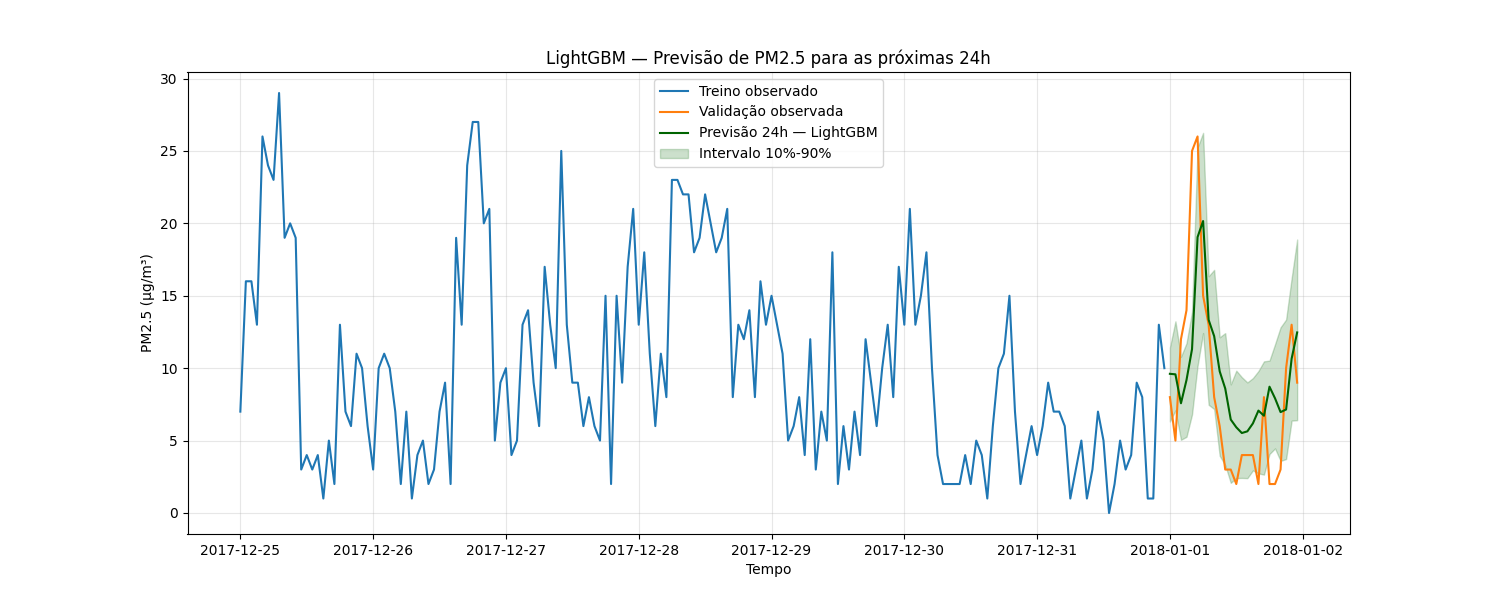

In [309]:
# treina dois modelos adicionais para os quantis
model_q10 = LGBMRegressor(objective="quantile", alpha=0.1,
                           n_estimators=500, random_state=42, verbose=-1)
model_q90 = LGBMRegressor(objective="quantile", alpha=0.9,
                           n_estimators=500, random_state=42, verbose=-1)

model_q10.fit(X_train, y_train)
model_q90.fit(X_train, y_train)

X_future  = X_val.iloc[:24]
pred_mean = pd.Series(model.predict(X_future),    index=X_future.index)
pred_low  = pd.Series(model_q10.predict(X_future), index=X_future.index)
pred_high = pd.Series(model_q90.predict(X_future), index=X_future.index)


plt.figure(figsize=(15, 6))

plt.plot(y_train.iloc[-24*7:], label="Treino observado")
plt.plot(y_val.iloc[:24],      label="Validação observada")
plt.plot(pred_mean, label="Previsão 24h — LightGBM", color="darkgreen")

plt.fill_between(
    pred_mean.index,
    pred_low,
    pred_high,
    alpha=0.2,
    color="darkgreen",
    label="Intervalo 10%-90%"
)

plt.title("LightGBM — Previsão de PM2.5 para as próximas 24h")
plt.xlabel("Tempo")
plt.ylabel("PM2.5 (µg/m³)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [310]:
error_mae = mean_absolute_error(
                y_true = y_val.iloc[:24],
                y_pred = pred_mean
            )
print(f"Test error (mae): {error_mae}")

Test error (mae): 4.1454733518791995


In [311]:
error_rmse = root_mean_squared_error(
    y_true=y_val.iloc[:24],
    y_pred=pred_mean
)

print(f"Test error (RMSE): {error_rmse:.3f}")

Test error (RMSE): 4.907


In [312]:
r2 = r2_score(
    y_true=y_val.iloc[:24],
    y_pred=pred_mean
)

print(f"R²: {r2:.4f}")

R²: 0.4472


**Learning Curve — LightGBM**

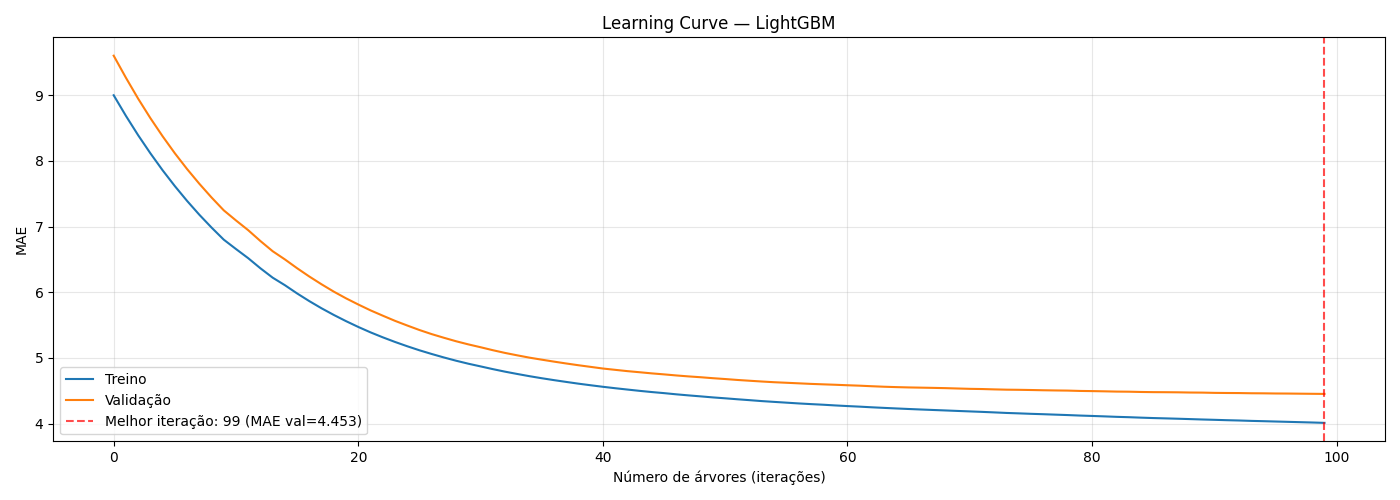

Melhor iteração : 99
MAE treino      : 4.013
MAE validação   : 4.453
Gap treino/val  : 0.441  (ideal próximo de 0)


In [313]:
# extraindo métricas por iteração
mae_train = model.evals_result_["treino"]["l1"]
mae_val   = model.evals_result_["validação"]["l1"]


fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(mae_train, label="Treino",    color="tab:blue",   linewidth=1.5)
ax.plot(mae_val,   label="Validação", color="tab:orange", linewidth=1.5)


best_iter = np.argmin(mae_val)
ax.axvline(best_iter, color="red", linestyle="--", alpha=0.7,
           label=f"Melhor iteração: {best_iter} (MAE val={mae_val[best_iter]:.3f})")

ax.set_title("Learning Curve — LightGBM")
ax.set_xlabel("Número de árvores (iterações)")
ax.set_ylabel("MAE")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Melhor iteração : {best_iter}")
print(f"MAE treino      : {mae_train[best_iter]:.3f}")
print(f"MAE validação   : {mae_val[best_iter]:.3f}")
print(f"Gap treino/val  : {mae_val[best_iter] - mae_train[best_iter]:.3f}  (ideal próximo de 0)")

**7.2 Avaliação de todo o conjunto de validação** 

In [ ]:
def walk_forward_lgbm(
    X_train, y_train,
    X_test,  y_test,
    horizon=24,
    step=24*7,
    start_inicial=0,
    output_file="walk_forward_lgbm.csv"
):
    """
    Walk-forward validation para LightGBM.
    Estrutura idêntica ao walk_forward_sarimax.
    """

    resultados = []

    X_total = pd.concat([X_train, X_test])
    y_total = pd.concat([y_train, y_test])

    n_test = len(y_test)

    for start in range(start_inicial, n_test - horizon + 1, step):

        print(f"Rodando previsão {start} até {start + horizon} de {n_test}...")

        # treino cresce a cada iteração
        X_train_i = X_total.iloc[:len(X_train) + start]
        y_train_i = y_total.iloc[:len(y_train) + start]

        # janela futura
        X_true_i = X_test.iloc[start:start + horizon]
        y_true_i = y_test.iloc[start:start + horizon]

        # testei mascarar tbm o Y com NaN, mas os resultados pioraram. Vou tirar somente do X por conta dos lags
        mask_train = X_train_i.notna().all(axis=1)

        X_fit = X_train_i[mask_train]
        y_fit = y_train_i[mask_train]

        # valores obtidos fazendo o GridSearch (random)
        model_i = LGBMRegressor(
            n_estimators=100,
            learning_rate=0.05,
            num_leaves=31,
            min_child_samples=50,
            min_child_weight=0.1,
            max_depth=15,
            subsample=0.6,
            colsample_bytree=0.8,
            reg_lambda=0.0,
            reg_alpha=0.1,
            random_state=42,
            verbose=-1
        )

        model_i.fit(X_fit, y_fit)

        y_pred_i = pd.Series(
            model_i.predict(X_true_i),
            index=y_true_i.index
        )

        # baseline: últimas 24h observadas
        y_baseline_i = y_total.iloc[
            len(y_train) + start - horizon : len(y_train) + start
        ].copy()

        y_baseline_i.index = y_true_i.index

        # para comparação
        mask_eval = y_true_i.notna() & y_baseline_i.notna()

        if mask_eval.sum() == 0:
            continue

        # métricas do modelo
        mae  = mean_absolute_error(y_true_i[mask_eval], y_pred_i[mask_eval])
        rmse = np.sqrt(mean_squared_error(y_true_i[mask_eval], y_pred_i[mask_eval]))
        r2   = r2_score(y_true_i[mask_eval], y_pred_i[mask_eval]) \
               if mask_eval.sum() > 1 else np.nan

        # métricas do baseline
        mae_baseline  = mean_absolute_error(y_true_i[mask_eval], y_baseline_i[mask_eval])
        rmse_baseline = np.sqrt(mean_squared_error(y_true_i[mask_eval], y_baseline_i[mask_eval]))
        r2_baseline   = r2_score(y_true_i[mask_eval], y_baseline_i[mask_eval]) \
                        if mask_eval.sum() > 1 else np.nan

        melhora_mae  = 100 * (mae_baseline - mae)  / mae_baseline  if mae_baseline  != 0 else np.nan
        melhora_rmse = 100 * (rmse_baseline - rmse) / rmse_baseline if rmse_baseline != 0 else np.nan

        resultados.append({
            "start"           : start,
            "inicio_previsao" : y_true_i.index[0],
            "fim_previsao"    : y_true_i.index[-1],
            "mes"             : str(y_true_i.index[0].to_period("M")),
            "n_obs"           : mask_eval.sum(),

            "mae_lgbm"        : mae,
            "rmse_lgbm"       : rmse,
            "r2_lgbm"         : r2,

            "mae_baseline"    : mae_baseline,
            "rmse_baseline"   : rmse_baseline,
            "r2_baseline"     : r2_baseline,

            "melhora_mae_%"   : melhora_mae,
            "melhora_rmse_%"  : melhora_rmse
        })

        pd.DataFrame(resultados).to_csv(output_file, index=False)

    return pd.DataFrame(resultados)

In [315]:
df_walk_val = walk_forward_lgbm(
    X_train, y_train,
    X_val,   y_val,
    horizon=24,
    step=24*7,
    output_file="../results/walk_forward_lgbm_val.csv"
)

Rodando previsão 0 até 24 de 8760...


/tmp/ipykernel_329316/413198016.py:90: UserWarning: Converting to Period representation will drop timezone information.
  "mes"             : str(y_true_i.index[0].to_period("M")),


Rodando previsão 168 até 192 de 8760...


/tmp/ipykernel_329316/413198016.py:90: UserWarning: Converting to Period representation will drop timezone information.
  "mes"             : str(y_true_i.index[0].to_period("M")),


Rodando previsão 336 até 360 de 8760...
Rodando previsão 504 até 528 de 8760...


/tmp/ipykernel_329316/413198016.py:90: UserWarning: Converting to Period representation will drop timezone information.
  "mes"             : str(y_true_i.index[0].to_period("M")),


Rodando previsão 672 até 696 de 8760...


/tmp/ipykernel_329316/413198016.py:90: UserWarning: Converting to Period representation will drop timezone information.
  "mes"             : str(y_true_i.index[0].to_period("M")),


Rodando previsão 840 até 864 de 8760...


/tmp/ipykernel_329316/413198016.py:90: UserWarning: Converting to Period representation will drop timezone information.
  "mes"             : str(y_true_i.index[0].to_period("M")),


Rodando previsão 1008 até 1032 de 8760...


/tmp/ipykernel_329316/413198016.py:90: UserWarning: Converting to Period representation will drop timezone information.
  "mes"             : str(y_true_i.index[0].to_period("M")),


Rodando previsão 1176 até 1200 de 8760...


/tmp/ipykernel_329316/413198016.py:90: UserWarning: Converting to Period representation will drop timezone information.
  "mes"             : str(y_true_i.index[0].to_period("M")),


Rodando previsão 1344 até 1368 de 8760...


/tmp/ipykernel_329316/413198016.py:90: UserWarning: Converting to Period representation will drop timezone information.
  "mes"             : str(y_true_i.index[0].to_period("M")),


Rodando previsão 1512 até 1536 de 8760...


/tmp/ipykernel_329316/413198016.py:90: UserWarning: Converting to Period representation will drop timezone information.
  "mes"             : str(y_true_i.index[0].to_period("M")),


Rodando previsão 1680 até 1704 de 8760...


/tmp/ipykernel_329316/413198016.py:90: UserWarning: Converting to Period representation will drop timezone information.
  "mes"             : str(y_true_i.index[0].to_period("M")),


Rodando previsão 1848 até 1872 de 8760...


/tmp/ipykernel_329316/413198016.py:90: UserWarning: Converting to Period representation will drop timezone information.
  "mes"             : str(y_true_i.index[0].to_period("M")),


Rodando previsão 2016 até 2040 de 8760...


/tmp/ipykernel_329316/413198016.py:90: UserWarning: Converting to Period representation will drop timezone information.
  "mes"             : str(y_true_i.index[0].to_period("M")),


Rodando previsão 2184 até 2208 de 8760...


/tmp/ipykernel_329316/413198016.py:90: UserWarning: Converting to Period representation will drop timezone information.
  "mes"             : str(y_true_i.index[0].to_period("M")),


Rodando previsão 2352 até 2376 de 8760...


/tmp/ipykernel_329316/413198016.py:90: UserWarning: Converting to Period representation will drop timezone information.
  "mes"             : str(y_true_i.index[0].to_period("M")),


Rodando previsão 2520 até 2544 de 8760...


/tmp/ipykernel_329316/413198016.py:90: UserWarning: Converting to Period representation will drop timezone information.
  "mes"             : str(y_true_i.index[0].to_period("M")),


Rodando previsão 2688 até 2712 de 8760...


/tmp/ipykernel_329316/413198016.py:90: UserWarning: Converting to Period representation will drop timezone information.
  "mes"             : str(y_true_i.index[0].to_period("M")),


Rodando previsão 2856 até 2880 de 8760...


/tmp/ipykernel_329316/413198016.py:90: UserWarning: Converting to Period representation will drop timezone information.
  "mes"             : str(y_true_i.index[0].to_period("M")),


Rodando previsão 3024 até 3048 de 8760...


/tmp/ipykernel_329316/413198016.py:90: UserWarning: Converting to Period representation will drop timezone information.
  "mes"             : str(y_true_i.index[0].to_period("M")),


Rodando previsão 3192 até 3216 de 8760...


/tmp/ipykernel_329316/413198016.py:90: UserWarning: Converting to Period representation will drop timezone information.
  "mes"             : str(y_true_i.index[0].to_period("M")),


Rodando previsão 3360 até 3384 de 8760...


/tmp/ipykernel_329316/413198016.py:90: UserWarning: Converting to Period representation will drop timezone information.
  "mes"             : str(y_true_i.index[0].to_period("M")),


Rodando previsão 3528 até 3552 de 8760...


/tmp/ipykernel_329316/413198016.py:90: UserWarning: Converting to Period representation will drop timezone information.
  "mes"             : str(y_true_i.index[0].to_period("M")),


Rodando previsão 3696 até 3720 de 8760...


/tmp/ipykernel_329316/413198016.py:90: UserWarning: Converting to Period representation will drop timezone information.
  "mes"             : str(y_true_i.index[0].to_period("M")),


Rodando previsão 3864 até 3888 de 8760...


/tmp/ipykernel_329316/413198016.py:90: UserWarning: Converting to Period representation will drop timezone information.
  "mes"             : str(y_true_i.index[0].to_period("M")),


Rodando previsão 4032 até 4056 de 8760...
Rodando previsão 4200 até 4224 de 8760...


/tmp/ipykernel_329316/413198016.py:90: UserWarning: Converting to Period representation will drop timezone information.
  "mes"             : str(y_true_i.index[0].to_period("M")),


Rodando previsão 4368 até 4392 de 8760...


/tmp/ipykernel_329316/413198016.py:90: UserWarning: Converting to Period representation will drop timezone information.
  "mes"             : str(y_true_i.index[0].to_period("M")),


Rodando previsão 4536 até 4560 de 8760...


/tmp/ipykernel_329316/413198016.py:90: UserWarning: Converting to Period representation will drop timezone information.
  "mes"             : str(y_true_i.index[0].to_period("M")),


Rodando previsão 4704 até 4728 de 8760...


/tmp/ipykernel_329316/413198016.py:90: UserWarning: Converting to Period representation will drop timezone information.
  "mes"             : str(y_true_i.index[0].to_period("M")),


Rodando previsão 4872 até 4896 de 8760...


/tmp/ipykernel_329316/413198016.py:90: UserWarning: Converting to Period representation will drop timezone information.
  "mes"             : str(y_true_i.index[0].to_period("M")),


Rodando previsão 5040 até 5064 de 8760...


/tmp/ipykernel_329316/413198016.py:90: UserWarning: Converting to Period representation will drop timezone information.
  "mes"             : str(y_true_i.index[0].to_period("M")),


Rodando previsão 5208 até 5232 de 8760...


/tmp/ipykernel_329316/413198016.py:90: UserWarning: Converting to Period representation will drop timezone information.
  "mes"             : str(y_true_i.index[0].to_period("M")),


Rodando previsão 5376 até 5400 de 8760...


/tmp/ipykernel_329316/413198016.py:90: UserWarning: Converting to Period representation will drop timezone information.
  "mes"             : str(y_true_i.index[0].to_period("M")),


Rodando previsão 5544 até 5568 de 8760...


/tmp/ipykernel_329316/413198016.py:90: UserWarning: Converting to Period representation will drop timezone information.
  "mes"             : str(y_true_i.index[0].to_period("M")),


Rodando previsão 5712 até 5736 de 8760...


/tmp/ipykernel_329316/413198016.py:90: UserWarning: Converting to Period representation will drop timezone information.
  "mes"             : str(y_true_i.index[0].to_period("M")),


Rodando previsão 5880 até 5904 de 8760...


/tmp/ipykernel_329316/413198016.py:90: UserWarning: Converting to Period representation will drop timezone information.
  "mes"             : str(y_true_i.index[0].to_period("M")),


Rodando previsão 6048 até 6072 de 8760...


/tmp/ipykernel_329316/413198016.py:90: UserWarning: Converting to Period representation will drop timezone information.
  "mes"             : str(y_true_i.index[0].to_period("M")),


Rodando previsão 6216 até 6240 de 8760...


/tmp/ipykernel_329316/413198016.py:90: UserWarning: Converting to Period representation will drop timezone information.
  "mes"             : str(y_true_i.index[0].to_period("M")),


Rodando previsão 6384 até 6408 de 8760...


/tmp/ipykernel_329316/413198016.py:90: UserWarning: Converting to Period representation will drop timezone information.
  "mes"             : str(y_true_i.index[0].to_period("M")),


Rodando previsão 6552 até 6576 de 8760...


/tmp/ipykernel_329316/413198016.py:90: UserWarning: Converting to Period representation will drop timezone information.
  "mes"             : str(y_true_i.index[0].to_period("M")),


Rodando previsão 6720 até 6744 de 8760...


/tmp/ipykernel_329316/413198016.py:90: UserWarning: Converting to Period representation will drop timezone information.
  "mes"             : str(y_true_i.index[0].to_period("M")),


Rodando previsão 6888 até 6912 de 8760...


/tmp/ipykernel_329316/413198016.py:90: UserWarning: Converting to Period representation will drop timezone information.
  "mes"             : str(y_true_i.index[0].to_period("M")),


Rodando previsão 7056 até 7080 de 8760...
Rodando previsão 7224 até 7248 de 8760...
Rodando previsão 7392 até 7416 de 8760...


/tmp/ipykernel_329316/413198016.py:90: UserWarning: Converting to Period representation will drop timezone information.
  "mes"             : str(y_true_i.index[0].to_period("M")),


Rodando previsão 7560 até 7584 de 8760...


/tmp/ipykernel_329316/413198016.py:90: UserWarning: Converting to Period representation will drop timezone information.
  "mes"             : str(y_true_i.index[0].to_period("M")),


Rodando previsão 7728 até 7752 de 8760...


/tmp/ipykernel_329316/413198016.py:90: UserWarning: Converting to Period representation will drop timezone information.
  "mes"             : str(y_true_i.index[0].to_period("M")),


Rodando previsão 7896 até 7920 de 8760...


/tmp/ipykernel_329316/413198016.py:90: UserWarning: Converting to Period representation will drop timezone information.
  "mes"             : str(y_true_i.index[0].to_period("M")),


Rodando previsão 8064 até 8088 de 8760...


/tmp/ipykernel_329316/413198016.py:90: UserWarning: Converting to Period representation will drop timezone information.
  "mes"             : str(y_true_i.index[0].to_period("M")),


Rodando previsão 8232 até 8256 de 8760...


/tmp/ipykernel_329316/413198016.py:90: UserWarning: Converting to Period representation will drop timezone information.
  "mes"             : str(y_true_i.index[0].to_period("M")),


Rodando previsão 8400 até 8424 de 8760...


/tmp/ipykernel_329316/413198016.py:90: UserWarning: Converting to Period representation will drop timezone information.
  "mes"             : str(y_true_i.index[0].to_period("M")),


Rodando previsão 8568 até 8592 de 8760...
Rodando previsão 8736 até 8760 de 8760...


/tmp/ipykernel_329316/413198016.py:90: UserWarning: Converting to Period representation will drop timezone information.
  "mes"             : str(y_true_i.index[0].to_period("M")),


In [316]:
df_walk_val[["mae_lgbm", "rmse_lgbm", "r2_lgbm",
         "mae_baseline", "melhora_mae_%"]].describe()

,mae_lgbm,rmse_lgbm,r2_lgbm,mae_baseline,melhora_mae_%
count,48.000000,48.000000,48.000000,48.000000,48.000000
mean,4.347508,5.550936,0.337551,8.469467,43.340524
std,1.243798,1.685658,0.285796,3.998367,16.616993
min,1.660712,1.766016,-0.298154,3.500000,6.826265
25%,3.523199,4.473223,0.109930,5.645833,32.155693
50%,4.185344,5.294596,0.398400,7.666667,44.374272
75%,4.956180,6.305766,0.540486,9.958333,57.671571
max,7.470363,11.104303,0.917227,23.541667,79.845018


**7.3 Comparando o desempenho na validação dos diferentes modelos**

In [317]:
#abrindo resultados do conjunto de validação (Melhor SARIMAX)
best_sarimax = pd.read_csv('../results/walk_forward_parcial_temp_umi_prec_wind_101_val.csv')
best_sarimax["inicio_previsao"] = pd.to_datetime(best_sarimax["inicio_previsao"])

In [318]:
#abrindo resultados do conjunto de validação (LightGBM/Dart)
dart = pd.read_csv('../results/walk_forward_lgbm_dart_val.csv')
dart["inicio_previsao"] = pd.to_datetime(dart["inicio_previsao"])
dart.head()

,start,inicio_previsao,fim_previsao,mes,n_obs,mae_lgbm,rmse_lgbm,r2_lgbm,mae_baseline,rmse_baseline,r2_baseline,melhora_mae_%,melhora_rmse_%
0,0,2018-01-01 00:00:00+00:00,2018-01-01 23:00:00+00:00,2018-01,24,4.125740,5.045148,0.415771,5.375000,7.536025,-0.303527,23.242048,33.052924
1,168,2018-01-08 00:00:00+00:00,2018-01-08 23:00:00+00:00,2018-01,24,3.330897,4.089892,-0.040146,5.750000,7.088723,-2.124690,42.071364,42.304253
2,504,2018-01-22 00:00:00+00:00,2018-01-22 23:00:00+00:00,2018-01,24,3.516650,4.565577,0.400128,8.666667,11.210114,-2.616488,59.423264,59.272698
3,672,2018-01-29 00:00:00+00:00,2018-01-29 23:00:00+00:00,2018-01,24,4.872015,6.053776,0.374408,13.916667,16.196707,-3.478084,64.991512,62.623416
4,840,2018-02-05 00:00:00+00:00,2018-02-05 23:00:00+00:00,2018-02,24,3.464162,4.811621,-0.023358,4.291667,5.255949,-0.221088,19.281663,8.453808


In [319]:
dart[["mae_lgbm", "rmse_lgbm", "r2_lgbm",
         "mae_baseline", "melhora_mae_%"]].describe()

,mae_lgbm,rmse_lgbm,r2_lgbm,mae_baseline,melhora_mae_%
count,48.000000,48.000000,48.000000,48.000000,48.000000
mean,4.387211,5.635490,0.313484,8.469467,42.643143
std,1.262508,1.701831,0.314722,3.998367,16.793646
min,2.443431,2.557539,-0.635252,3.500000,8.311514
25%,3.503528,4.560531,0.097076,5.645833,31.265379
50%,4.038574,5.236659,0.385354,7.666667,42.661320
75%,5.014169,6.609700,0.535961,9.958333,58.525882
max,7.441526,10.176052,0.888396,23.541667,79.820492


In [320]:
#abrindo resultados do melhor ajuste para o LightGBM
lgbm = pd.read_csv('../results/walk_forward_lgbm_val.csv')
lgbm["inicio_previsao"] = pd.to_datetime(lgbm["inicio_previsao"])
lgbm.head()

,start,inicio_previsao,fim_previsao,mes,n_obs,mae_lgbm,rmse_lgbm,r2_lgbm,mae_baseline,rmse_baseline,r2_baseline,melhora_mae_%,melhora_rmse_%
0,0,2018-01-01 00:00:00+00:00,2018-01-01 23:00:00+00:00,2018-01,24,4.235267,5.017784,0.422091,5.375000,7.536025,-0.303527,21.204333,33.416034
1,168,2018-01-08 00:00:00+00:00,2018-01-08 23:00:00+00:00,2018-01,24,3.306423,4.103372,-0.047014,5.750000,7.088723,-2.124690,42.496984,42.114085
2,504,2018-01-22 00:00:00+00:00,2018-01-22 23:00:00+00:00,2018-01,24,3.639552,4.538426,0.407242,8.666667,11.210114,-2.616488,58.005164,59.514903
3,672,2018-01-29 00:00:00+00:00,2018-01-29 23:00:00+00:00,2018-01,24,4.437345,5.637053,0.457571,13.916667,16.196707,-3.478084,68.114890,65.196303
4,840,2018-02-05 00:00:00+00:00,2018-02-05 23:00:00+00:00,2018-02,24,3.517421,4.914081,-0.067405,4.291667,5.255949,-0.221088,18.040666,6.504394


In [321]:
lgbm[["mae_lgbm", "rmse_lgbm", "r2_lgbm",
         "mae_baseline", "melhora_mae_%"]].describe()

,mae_lgbm,rmse_lgbm,r2_lgbm,mae_baseline,melhora_mae_%
count,48.000000,48.000000,48.000000,48.000000,48.000000
mean,4.347508,5.550936,0.337551,8.469467,43.340524
std,1.243798,1.685658,0.285796,3.998367,16.616993
min,1.660712,1.766016,-0.298154,3.500000,6.826265
25%,3.523199,4.473223,0.109930,5.645833,32.155693
50%,4.185344,5.294596,0.398400,7.666667,44.374272
75%,4.956180,6.305766,0.540486,9.958333,57.671571
max,7.470363,11.104303,0.917227,23.541667,79.845018


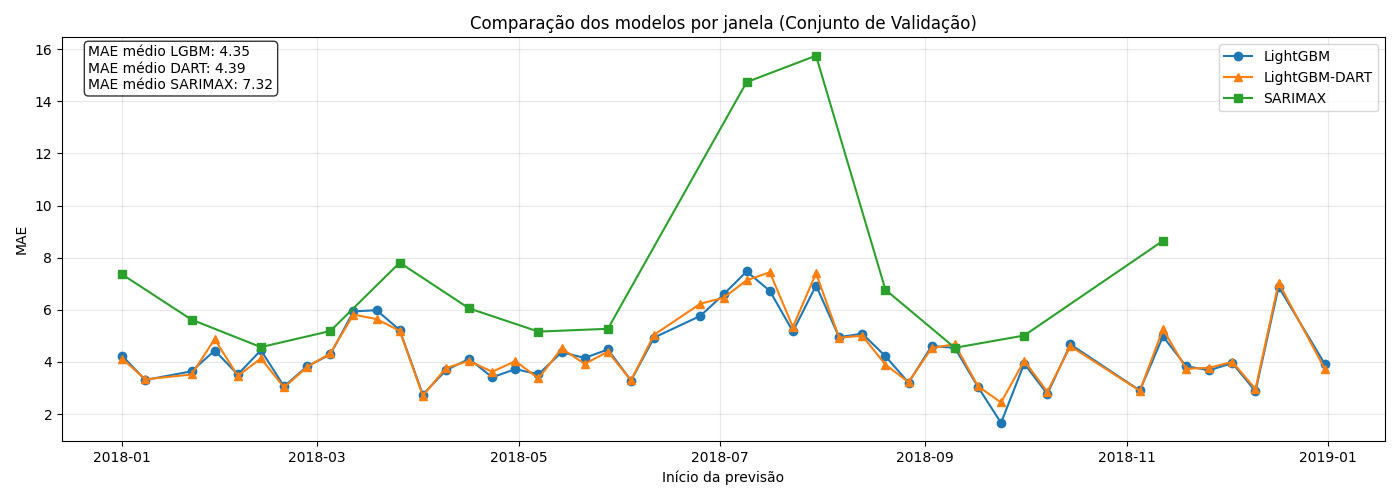

In [322]:
mae_lgbm = lgbm["mae_lgbm"].mean()
mae_dart = dart["mae_lgbm"].mean()
mae_sarimax = best_sarimax["mae_sarimax"].mean()

plt.figure(figsize=(14,5))

# LightGBM
plt.plot(
    df_walk_val["inicio_previsao"],
    df_walk_val["mae_lgbm"],
    marker="o",
    label="LightGBM"
)

# DART
plt.plot(
    dart["inicio_previsao"],
    dart["mae_lgbm"],
    marker="^",
    label="LightGBM-DART"
)

# SARIMAX
plt.plot(
    best_sarimax["inicio_previsao"],
    best_sarimax["mae_sarimax"],
    marker="s",
    label="SARIMAX"
)

texto = (
    f"MAE médio LGBM: {mae_lgbm:.2f}\n"
    f"MAE médio DART: {mae_dart:.2f}\n"
    f"MAE médio SARIMAX: {mae_sarimax:.2f}"
)

plt.text(
    0.02,
    0.98,
    texto,
    transform=plt.gca().transAxes,
    fontsize=10,
    verticalalignment="top",
    bbox=dict(
        boxstyle="round",
        facecolor="white",
        alpha=0.8
    )
)

plt.title("Comparação dos modelos por janela (Conjunto de Validação)")
plt.xlabel("Início da previsão")
plt.ylabel("MAE")
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

**SearchGRID**

In [323]:
# # remove nan
# mask = X_train.notna().all(axis=1) & y_train.notna()
# X_train_clean = X_train[mask]
# y_train_clean = y_train[mask]

In [324]:
# print("NaN em y_train:", y_train.isna().sum())
# print("NaN em X_train:", X_train.isna().any(axis=1).sum())

In [325]:
# # # espaço de busca
# # param_grid = {
# #     "learning_rate"    : [0.01, 0.05, 0.1],
# #     "num_leaves"       : [31, 63],
# #     "min_child_samples": [10, 20, 50],
# #     "subsample"        : [0.6, 0.8, 1.0],
# #     "colsample_bytree" : [0.6, 0.8, 1.0],
# # }
# ## results: {'subsample': 0.6, 'num_leaves': 31, 'min_child_samples': 50, 'learning_rate': 0.05, 'colsample_bytree': 0.8}

# # param_grid = {
# #     "n_estimators"     : [100, 200, 300],
# # }
# # Melhores parâmetros: {'n_estimators': 100}

# param_grid = {
#     "n_estimators"     : [100],
#     "learning_rate"    : [0.05],
#     "num_leaves"       : [31],
#     "max_depth"        : [-1, 10, 15],
#     "min_child_samples": [50],
#     "min_child_weight" : [1e-3, 0.1],
#     "subsample"        : [0.6],
#     "colsample_bytree" : [0.8],
#     "reg_alpha"        : [0.0, 0.1, 0.5],  # L1
#     "reg_lambda"       : [0.0, 0.1, 0.5, 1.0],  # L2
# }

# # TimeSeriesSplit — respeita ordem temporal
# # n_splits=5 cria 5 janelas de treino/validação crescentes
# tscv = TimeSeriesSplit(n_splits=3)

# search = RandomizedSearchCV(
#     estimator=LGBMRegressor(random_state=42, verbose=-1),
#     param_distributions=param_grid,
#     n_iter=50,
#     cv=tscv,
#     scoring="neg_mean_absolute_error",  # MAE negativo
#     n_jobs=-1,
#     random_state=42,
#     verbose=1
# )

# search.fit(X_train_clean, y_train_clean)

# print("Melhores parâmetros:")
# print(search.best_params_)
# print(f"\nMelhor MAE (cv): {-search.best_score_:.3f}")

Melhores parâmetros:
    {'subsample': 0.6, 'reg_lambda': 0.0, 'reg_alpha': 0.1, 'num_leaves': 31, 'n_estimators': 100, 'min_child_weight': 0.1, 'min_child_samples': 50, 'max_depth': 15, 'learning_rate': 0.05, 'colsample_bytree': 0.8}

Melhor MAE (cv): 4.552

**7.4 Avaliação de todo o conjunto de teste** 

In [326]:
df_walk_test = walk_forward_lgbm(
    X_train, y_train,
    X_test, y_test,
    horizon=24,
    step=24*7,
    output_file="../results/walk_forward_lgbm_test.csv"
)

Rodando previsão 0 até 24 de 5499...


/tmp/ipykernel_329316/413198016.py:90: UserWarning: Converting to Period representation will drop timezone information.
  "mes"             : str(y_true_i.index[0].to_period("M")),


Rodando previsão 168 até 192 de 5499...


/tmp/ipykernel_329316/413198016.py:90: UserWarning: Converting to Period representation will drop timezone information.
  "mes"             : str(y_true_i.index[0].to_period("M")),


Rodando previsão 336 até 360 de 5499...


/tmp/ipykernel_329316/413198016.py:90: UserWarning: Converting to Period representation will drop timezone information.
  "mes"             : str(y_true_i.index[0].to_period("M")),


Rodando previsão 504 até 528 de 5499...


/tmp/ipykernel_329316/413198016.py:90: UserWarning: Converting to Period representation will drop timezone information.
  "mes"             : str(y_true_i.index[0].to_period("M")),


Rodando previsão 672 até 696 de 5499...


/tmp/ipykernel_329316/413198016.py:90: UserWarning: Converting to Period representation will drop timezone information.
  "mes"             : str(y_true_i.index[0].to_period("M")),


Rodando previsão 840 até 864 de 5499...


/tmp/ipykernel_329316/413198016.py:90: UserWarning: Converting to Period representation will drop timezone information.
  "mes"             : str(y_true_i.index[0].to_period("M")),


Rodando previsão 1008 até 1032 de 5499...


/tmp/ipykernel_329316/413198016.py:90: UserWarning: Converting to Period representation will drop timezone information.
  "mes"             : str(y_true_i.index[0].to_period("M")),


Rodando previsão 1176 até 1200 de 5499...


/tmp/ipykernel_329316/413198016.py:90: UserWarning: Converting to Period representation will drop timezone information.
  "mes"             : str(y_true_i.index[0].to_period("M")),


Rodando previsão 1344 até 1368 de 5499...


/tmp/ipykernel_329316/413198016.py:90: UserWarning: Converting to Period representation will drop timezone information.
  "mes"             : str(y_true_i.index[0].to_period("M")),


Rodando previsão 1512 até 1536 de 5499...


/tmp/ipykernel_329316/413198016.py:90: UserWarning: Converting to Period representation will drop timezone information.
  "mes"             : str(y_true_i.index[0].to_period("M")),


Rodando previsão 1680 até 1704 de 5499...


/tmp/ipykernel_329316/413198016.py:90: UserWarning: Converting to Period representation will drop timezone information.
  "mes"             : str(y_true_i.index[0].to_period("M")),


Rodando previsão 1848 até 1872 de 5499...


/tmp/ipykernel_329316/413198016.py:90: UserWarning: Converting to Period representation will drop timezone information.
  "mes"             : str(y_true_i.index[0].to_period("M")),


Rodando previsão 2016 até 2040 de 5499...


/tmp/ipykernel_329316/413198016.py:90: UserWarning: Converting to Period representation will drop timezone information.
  "mes"             : str(y_true_i.index[0].to_period("M")),


Rodando previsão 2184 até 2208 de 5499...


/tmp/ipykernel_329316/413198016.py:90: UserWarning: Converting to Period representation will drop timezone information.
  "mes"             : str(y_true_i.index[0].to_period("M")),


Rodando previsão 2352 até 2376 de 5499...


/tmp/ipykernel_329316/413198016.py:90: UserWarning: Converting to Period representation will drop timezone information.
  "mes"             : str(y_true_i.index[0].to_period("M")),


Rodando previsão 2520 até 2544 de 5499...


/tmp/ipykernel_329316/413198016.py:90: UserWarning: Converting to Period representation will drop timezone information.
  "mes"             : str(y_true_i.index[0].to_period("M")),


Rodando previsão 2688 até 2712 de 5499...


/tmp/ipykernel_329316/413198016.py:90: UserWarning: Converting to Period representation will drop timezone information.
  "mes"             : str(y_true_i.index[0].to_period("M")),


Rodando previsão 2856 até 2880 de 5499...


/tmp/ipykernel_329316/413198016.py:90: UserWarning: Converting to Period representation will drop timezone information.
  "mes"             : str(y_true_i.index[0].to_period("M")),


Rodando previsão 3024 até 3048 de 5499...


/tmp/ipykernel_329316/413198016.py:90: UserWarning: Converting to Period representation will drop timezone information.
  "mes"             : str(y_true_i.index[0].to_period("M")),


Rodando previsão 3192 até 3216 de 5499...


/tmp/ipykernel_329316/413198016.py:90: UserWarning: Converting to Period representation will drop timezone information.
  "mes"             : str(y_true_i.index[0].to_period("M")),


Rodando previsão 3360 até 3384 de 5499...


/tmp/ipykernel_329316/413198016.py:90: UserWarning: Converting to Period representation will drop timezone information.
  "mes"             : str(y_true_i.index[0].to_period("M")),


Rodando previsão 3528 até 3552 de 5499...


/tmp/ipykernel_329316/413198016.py:90: UserWarning: Converting to Period representation will drop timezone information.
  "mes"             : str(y_true_i.index[0].to_period("M")),


Rodando previsão 3696 até 3720 de 5499...


/tmp/ipykernel_329316/413198016.py:90: UserWarning: Converting to Period representation will drop timezone information.
  "mes"             : str(y_true_i.index[0].to_period("M")),


Rodando previsão 3864 até 3888 de 5499...


/tmp/ipykernel_329316/413198016.py:90: UserWarning: Converting to Period representation will drop timezone information.
  "mes"             : str(y_true_i.index[0].to_period("M")),


Rodando previsão 4032 até 4056 de 5499...


/tmp/ipykernel_329316/413198016.py:90: UserWarning: Converting to Period representation will drop timezone information.
  "mes"             : str(y_true_i.index[0].to_period("M")),


Rodando previsão 4200 até 4224 de 5499...


/tmp/ipykernel_329316/413198016.py:90: UserWarning: Converting to Period representation will drop timezone information.
  "mes"             : str(y_true_i.index[0].to_period("M")),


Rodando previsão 4368 até 4392 de 5499...


/tmp/ipykernel_329316/413198016.py:90: UserWarning: Converting to Period representation will drop timezone information.
  "mes"             : str(y_true_i.index[0].to_period("M")),


Rodando previsão 4536 até 4560 de 5499...


/tmp/ipykernel_329316/413198016.py:90: UserWarning: Converting to Period representation will drop timezone information.
  "mes"             : str(y_true_i.index[0].to_period("M")),


Rodando previsão 4704 até 4728 de 5499...


/tmp/ipykernel_329316/413198016.py:90: UserWarning: Converting to Period representation will drop timezone information.
  "mes"             : str(y_true_i.index[0].to_period("M")),


Rodando previsão 4872 até 4896 de 5499...


/tmp/ipykernel_329316/413198016.py:90: UserWarning: Converting to Period representation will drop timezone information.
  "mes"             : str(y_true_i.index[0].to_period("M")),


Rodando previsão 5040 até 5064 de 5499...


/tmp/ipykernel_329316/413198016.py:90: UserWarning: Converting to Period representation will drop timezone information.
  "mes"             : str(y_true_i.index[0].to_period("M")),


Rodando previsão 5208 até 5232 de 5499...
Rodando previsão 5376 até 5400 de 5499...


/tmp/ipykernel_329316/413198016.py:90: UserWarning: Converting to Period representation will drop timezone information.
  "mes"             : str(y_true_i.index[0].to_period("M")),


In [327]:
df_walk_test[["mae_lgbm", "rmse_lgbm", "r2_lgbm",
         "mae_baseline", "melhora_mae_%"]].describe()

,mae_lgbm,rmse_lgbm,r2_lgbm,mae_baseline,melhora_mae_%
count,32.000000,32.000000,32.000000,32.000000,32.000000
mean,4.840314,6.188087,0.331762,9.545501,42.208512
std,1.281299,1.710938,0.327516,5.427076,18.152285
min,2.044861,2.523979,-0.424384,3.750000,-8.001187
25%,3.950097,5.326303,0.107292,6.187500,31.620313
50%,4.773005,5.958957,0.364958,7.666667,45.651593
75%,5.453507,6.918766,0.569291,11.791667,55.429575
max,8.365556,10.755944,0.881769,31.652174,74.340440


In [328]:
#abrindo teste do melhor SARIMAX
best_sarimax = pd.read_csv('../results/walk_forward_parcial_temp_umi_prec_wind_101_teste.csv')
best_sarimax["inicio_previsao"] = pd.to_datetime(best_sarimax["inicio_previsao"])

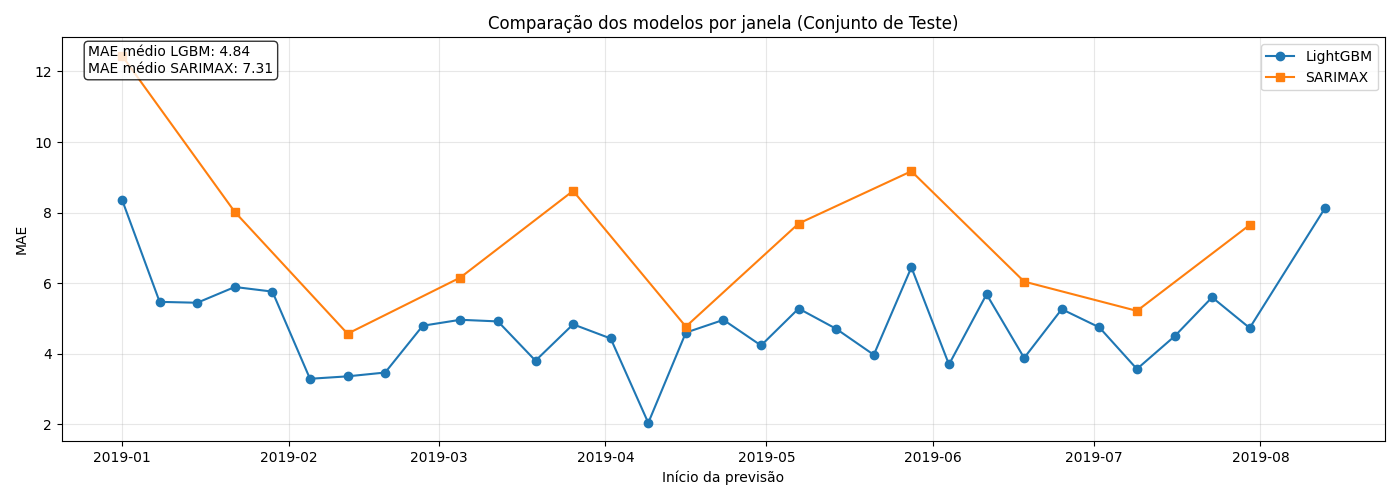

In [329]:
mae_lgbm = df_walk_test["mae_lgbm"].mean()
mae_sarimax = best_sarimax["mae_sarimax"].mean()

plt.figure(figsize=(14,5))

# LightGBM
plt.plot(
    df_walk_test["inicio_previsao"],
    df_walk_test["mae_lgbm"],
    marker="o",
    label="LightGBM"
)

# SARIMAX
plt.plot(
    best_sarimax["inicio_previsao"],
    best_sarimax["mae_sarimax"],
    marker="s",
    label="SARIMAX"
)

texto = (
    f"MAE médio LGBM: {mae_lgbm:.2f}\n"
    f"MAE médio SARIMAX: {mae_sarimax:.2f}"
)

plt.text(
    0.02,
    0.98,
    texto,
    transform=plt.gca().transAxes,
    fontsize=10,
    verticalalignment="top",
    bbox=dict(
        boxstyle="round",
        facecolor="white",
        alpha=0.8
    )
)

plt.title("Comparação dos modelos por janela (Conjunto de Teste)")
plt.xlabel("Início da previsão")
plt.ylabel("MAE")
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()